### Chi-Square Test
    The Chi-Square Test is a statistical hypothesis test used to analyze categorical data.

    the Chi-Square Test compares frequencies or counts.

    It helps determine whether the observed frequencies differ significantly from the expected frequencies.

    Ex: Perform On Categorical Data
        - Gender
        - Department
        - Product Category

### Use the Chi-Square Test when
    - The data is categorical.
    - The observations are independent.
    - The data is represented as frequencies or counts.
    - The expected frequency in each category is generally at least 5.
    - The data should represent frequencies (counts), not percentages, averages, or continuous values.


### The test statistic follows a probability distribution called the
    Chi-Square Distribution.

    This distribution is always
        - Positive
        - Right-skewed
        - Dependent on the Degrees of Freedom


### Degrees of Freedom
    For the Chi-Square Goodness of Fit Test

$$
df=k-1
$$

            where
                - $k$ = Number of categories

    For the Chi-Square Test of Independence

$$
df=(r-1)(c-1)
$$

            where
                - $r$ = Number of rows
                - $c$ = Number of columns

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import scipy.stats as sts

In [47]:

products = pd.DataFrame({

    "Product":["A","B","C","D"],

    "Customers":[52,61,45,42]

})

products

,Product,Customers
0,A,52
1,B,61
2,C,45
3,D,42


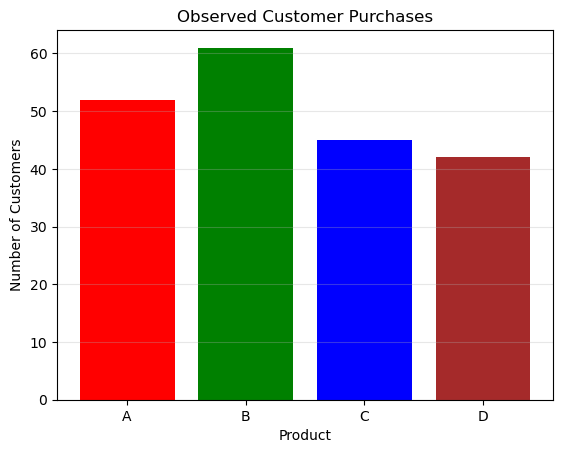

In [48]:
C=['r','g','b','brown']

plt.bar(

    products["Product"],

    products["Customers"],

    color=C
)

plt.title("Observed Customer Purchases")

plt.xlabel("Product")

plt.ylabel("Number of Customers")

plt.grid(axis="y", alpha=0.3)

plt.show()

# Types Of Chi-Square Test

## 1. Chi-Square Goodness of Fit Test
    The Chi-Square Goodness of Fit Test is used to determine whether the observed frequencies differ significantly from the expected frequencies.

    It compares the actual counts collected from the sample with the counts that are expected under the Null Hypothesis.

### Business Problem

    retail company sells four products.The management believes that customers purchase all four products equally.

    To verify this claim,

    the company records the number of customers purchasing each product.

    The objective is to determine whether the observed customer purchases differ significantly from the expected distribution.

### State the Hypotheses
    Null Hypothesis

$$
H_0:
\text{The observed frequencies are equal to the expected frequencies.}
$$

        The products are purchased equally.

    Alternative Hypothesis

$$
H_1:
\text{The observed frequencies are not equal to the expected frequencies.}
$$

        The products are not purchased equally.

### Significance Level

$$
\alpha=0.05
$$

In [54]:
print("Obeserved Frequencies")

observed = np.array([52,61,45,42])

products = ["A","B","C","D"]

pd.DataFrame({

    "Product":products,

    "Observed":observed.flatten()

})


Obeserved Frequencies


,Product,Observed
0,A,52
1,B,61
2,C,45
3,D,42


###  Expected Frequencies
    If all products are purchased equally,

    the expected frequency is

$$
E=\frac{\text{Total Customers}}{\text{Number of Categories}}
$$

In [58]:
total = observed.sum()

k = len(observed)

expected = np.repeat( total / k , k)

expected

array([50., 50., 50., 50.])

In [57]:
comp = pd.DataFrame({

    "Product":products,

    "Observed":observed,

    "Expected":expected

})

comp

,Product,Observed,Expected
0,A,52,50.0
1,B,61,50.0
2,C,45,50.0
3,D,42,50.0


### Chi-Square Formula
    The Chi-Square Statistic is calculated as

$$
\chi^2=
\sum
\frac{(O-E)^2}{E}
$$

    where
- $O$ = Observed Frequency

- $E$ = Expected Frequency

### Manual Calculation

| Product | O | E | (O-E) | (O-E)² | (O-E)²/E |
|---------|---:|---:|------:|--------:|----------:|
| A | 52 | 50 | 2 | 4 | 0.08 |
| B | 61 | 50 | 11 | 121 | 2.42 |
| C | 45 | 50 | -5 | 25 | 0.50 |
| D | 42 | 50 | -8 | 64 | 1.28 |

    Therefore,

$$
\chi^2
=
0.08
+
2.42
+
0.50
+
1.28
=
4.28
$$

In [10]:
chi_manual = np.sum(
                     ((observed - expected)**2) / expected 
                   )

print(f"Chi-Square Statistic : {chi_manual:.2f}")

Chi-Square Statistic : 4.28


In [11]:
# Degrees Of Freedom

df = len(observed) - 1

print(df)

3


### Perform the Chi-Square Test Using Python

In [12]:
from scipy.stats import chisquare

chi_statistic, p_value = chisquare(

    f_obs=observed,

    f_exp=expected

)

print(f"Chi-Square Statistic : {chi_statistic:.2f}")

print(f"p-value : {p_value:.4f}")

Chi-Square Statistic : 4.28
p-value : 0.2328


### Make the Statistical Decision
    Decision Rule

    If

$$
p\le0.05
$$

            Reject the Null Hypothesis.

    Otherwise,
            Fail to Reject the Null Hypothesis.

In [13]:
alpha = 0.05

if p_value <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


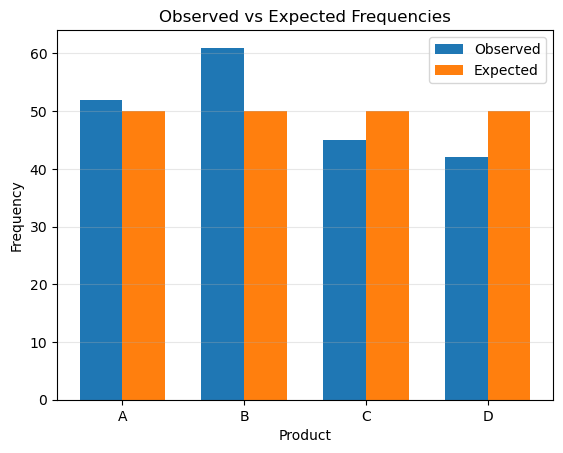

In [16]:
x = np.arange(len(products))

width=0.35

plt.bar( x-width/2,

        observed,

        width,

        label="Observed"

  )

plt.bar(  x+width/2, 
        expected, 
        width, 
        label="Expected"

)

plt.xticks( x, products )

plt.xlabel("Product")

plt.ylabel("Frequency")

plt.title("Observed vs Expected Frequencies")

plt.legend()

plt.grid(axis="y",alpha=0.3)

plt.show()

### Key Points
    - The Goodness of Fit Test compares observed and expected frequencies.
    - It is used for one categorical variable.
    - The test statistic follows the Chi-Square Distribution.
    - The p-value determines the statistical decision.
    - The Chi-Square Test does not compare means; it compares frequencies.

# Chi-Square Test of Independence
    The Chi-Square Test of Independence is used to determine whether two categorical variables are associated.

    It compares the observed frequencies in a contingency table with the expected frequencies under the assumption that the variables are independent.

    this test analyzes the relationship between two categorical variables.

### Business Problem
    A retail company wants to determine whether customer gender influences the preferred payment method.

    A random sample of customers is collected.

    The company records
        - Customer Gender
        - Preferred Payment Method

    The objective is to determine whether Gender and Payment Method are associated.

### State the Hypotheses
    Null Hypothesis

$$
H_0:
\text{Gender and Payment Method are independent.}
$$

            There is no relationship between Gender and Payment Method.
    
    Alternative Hypothesis

$$
H_1:
\text{Gender and Payment Method are dependent.}
$$

    There is a relationship between Gender and Payment Method.

In [2]:
print("'Given Observed Frequency Table'")

observed = pd.DataFrame({
    "Cash": [40, 25],
    "Card": [30, 45],
    "UPI": [50, 60]
}, index=["Male", "Female"])

# Add Row Total
observed["Total"] = observed.sum(axis=1)

# Add Column Total
observed.loc["Total"] = observed.sum(axis=0)

observed



'Given Observed Frequency Table'


,Cash,Card,UPI,Total
Male,40,30,50,120
Female,25,45,60,130
Total,65,75,110,250


### Contingency Table
    A contingency table shows the frequency of observations for two categorical variables.

    Each cell represents the number of observations belonging to a particular combination of categories.

In [5]:
observed

,Cash,Card,UPI,Total
Male,40,30,50,120
Female,25,45,60,130
Total,65,75,110,250


### Expected Frequency Formula
    Expected Frequency is calculated as

$$
E=
\frac{
(Row\ Total)
\times
(Column\ Total)
}
{
Grand\ Total
}
$$

In [8]:
# E(40)=(120*65)/250, E(60)=(130*110)/250

observed = pd.DataFrame({
    "Cash": [40, 25],
    "Card": [30, 45],
    "UPI": [50, 60]
}, index=["Male", "Female"])

# Calculate Expected Frequencies
row_total = observed.sum(axis=1)
col_total = observed.sum(axis=0)
grand_total = observed.values.sum()

expected = pd.DataFrame(
    row_total.values.reshape(-1, 1) * col_total.values / grand_total,
    index=observed.index,
    columns=observed.columns
).round(2)

# Add Row Total
expected["Total"] = expected.sum(axis=1)

# Add Column Total
expected.loc["Total"] = expected.sum(axis=0)

expected

,Cash,Card,UPI,Total
Male,31.2,36.0,52.8,120.0
Female,33.8,39.0,57.2,130.0
Total,65.0,75.0,110.0,250.0


###  Degrees of Freedom
    Formula

$$
df=(r-1)(c-1)
$$

    where
- $r$ = Number of Rows

- $c$ = Number of Columns

In [25]:
rows = observed.shape[0]

columns = observed.shape[1]

df_manual = (rows-1)*(columns-1)

print(df_manual)

2


In [23]:
from scipy.stats import chi2_contingency

chi_statistic, p_value, df, expected = chi2_contingency(  observed  )

print(f"Chi-Square Statistic : {chi_statistic:.2f}\n")

print(f"p-value : {p_value:.4f}\n")

print(f"Degrees of Freedom : {df}")

Chi-Square Statistic : 6.98

p-value : 0.0305

Degrees of Freedom : 2


In [26]:
alpha = 0.05

p_value= 0.0305

if p_value <= alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Reject the Null Hypothesis


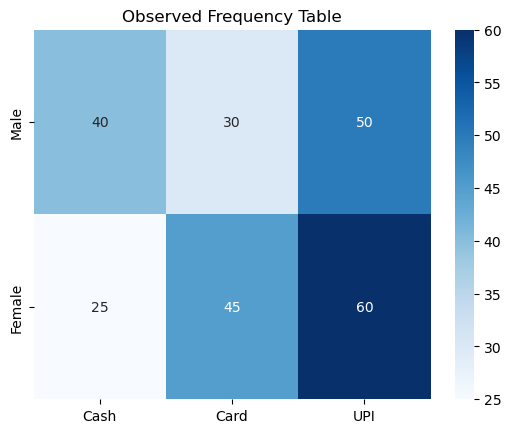

In [29]:
import seaborn as sns

sns.heatmap(

    observed,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title("Observed Frequency Table")

plt.show()

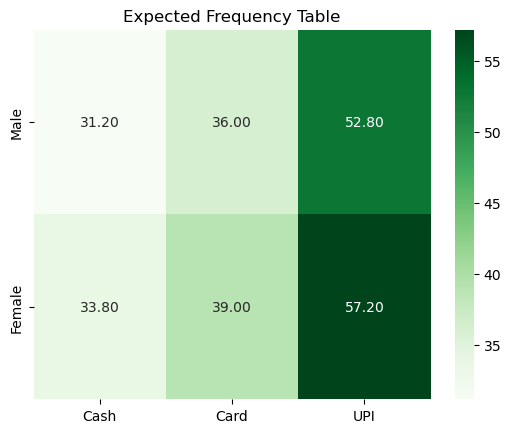

In [30]:
sns.heatmap(

    expected_table,

    annot=True,

    fmt=".2f",

    cmap="Greens"

)

plt.title("Expected Frequency Table")

plt.show()

### Goodness of Fit vs Test of Independence

| Goodness of Fit | Test of Independence |
|-----------------|----------------------|
| One categorical variable | Two categorical variables |
| Compare observed and expected frequencies | Determine relationship between two variables |
| Uses one frequency table | Uses a contingency table |
| Example: Product preference | Example: Gender vs Payment Method |

### Limitations of the Chi-Square Test
    - Applicable only to categorical data.
    - Sensitive to very small expected frequencies.
    - Does not measure the strength of a relationship.
    - Requires independent observations.
    - Does not indicate the direction of an association.

# The Chi-Square test statistic for population variance 
    A manufacturing company claims that the variance of the diameters produced by its machine is

$$
\sigma^2 = 25\text{ m}^2
$$

    A quality engineer randomly selects 20 products and measures their diameters.

    The engineer wants to determine whether the actual population variance is significantly different from the claimed variance at the 5% significance level.

### State the Hypotheses
    Null Hypothesis

$$
H_0:\sigma^2=25
$$

        The population variance is equal to 25.
---
    Alternative Hypothesis

$$
H_1:\sigma^2\neq25
$$

    The population variance is different from 25.

### The Chi-Square test statistic for population variance is

$$
\chi^2=
\frac{(n-1)s^2}{\sigma_0^2}
$$
    
    where

- $n$ = Sample Size
- $s^2$ = Sample Variance
- $\sigma_0^2$ = Claimed Population Variance

### Substitute the values

$$
\chi^2=
\frac{(20-1)\times36}{25}
$$

$$
=
\frac{684}{25}
$$

$$
=
27.36
$$

Therefore,

$$
\chi^2=27.36
$$

In [5]:
from scipy.stats import chi2
n = 20

sample_variance = 36

population_variance = 25

alpha = 0.05

df = n - 1

chi_statistic = ((n - 1) * sample_variance) / population_variance

print(f"Chi-Square Statistic : {chi_statistic:.2f}")

Chi-Square Statistic : 27.36


In [6]:
lower = chi2.ppf(alpha/2, df)

upper = chi2.ppf(1-alpha/2, df)

print(f"Lower Critical Value : {lower:.2f}")

print(f"Upper Critical Value : {upper:.2f}")

Lower Critical Value : 8.91
Upper Critical Value : 32.85


In [7]:
if chi_statistic < lower or chi_statistic > upper:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


### Problem :- Right Tailed
    A manufacturing company claims that the variance of the machine output is

$$
\sigma^2=25
$$

    A quality engineer believes that the machine has become less consistent and that the population variance is greater than 25.

    A random sample of 20 products is collected to test this claim.

### Hypothesis
    Null Hypothesis
$$
H_0:\sigma^2=25
$$

    Alternative Hypothesis
$$
H_1:\sigma^2>25
$$

In [24]:
n = 20

sample_variance = 36

population_variance = 25

chi_calR = ((n - 1) * sample_variance) / population_variance

print("Chi-Square Statistic :", round(chi_calR, 2))

Chi-Square Statistic : 27.36


In [21]:
# Criticak Value Means Chi-Square Table
alpha = 0.05

df = n - 1

criticalR = chi2.ppf(1-alpha, df)

print(criticalR)

30.14352720564616


In [25]:
if chi_calR > criticalR:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


In [33]:
# P-value:- Use sf() because it returns the right-tail probability.
p_value = chi2.sf(chi_calR, df)

print(p_value)

0.09654312116845057


### Problem :- Left Tailed
    A manufacturing company claims that the population variance is
$$
\sigma^2=25
$$
    
    A quality engineer believes that a new machine has reduced the variation in production.

    A random sample of 20 products is collected.

### Hypothesis
    Null Hypothesis
$$
H_0:\sigma^2=25
$$

    Alternative Hypothesis
$$
H_1:\sigma^2<25
$$

In [28]:
n = 20

sample_variance = 16

population_variance = 25

alpha = 0.05

chi_calL = ((n - 1) * sample_variance) / population_variance

print("Chi-Square Statistic :", round(chi_calL,2))

Chi-Square Statistic : 12.16


In [29]:
alpha = 0.05

df = n - 1

criticalL = chi2.ppf(alpha, df)

print(critical)

10.117013063859044


In [30]:
if chi_calL < criticalL:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis


In [34]:
# p-value:- Use cdf() because it returns the left-tail probability. 
# It compares With Alpha(0.05) Value To Give Decision Rule
p_value = chi2.cdf(chi_calL, df)

print(p_value)

0.12132722424642757


### Decision Using P_value

In [35]:
if p_value < alpha:

    print("Reject the Null Hypothesis")

else:

    print("Fail to Reject the Null Hypothesis")

Fail to Reject the Null Hypothesis
